Размер датасета: (442, 11)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Инфо:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

Описание:
                age           sex       

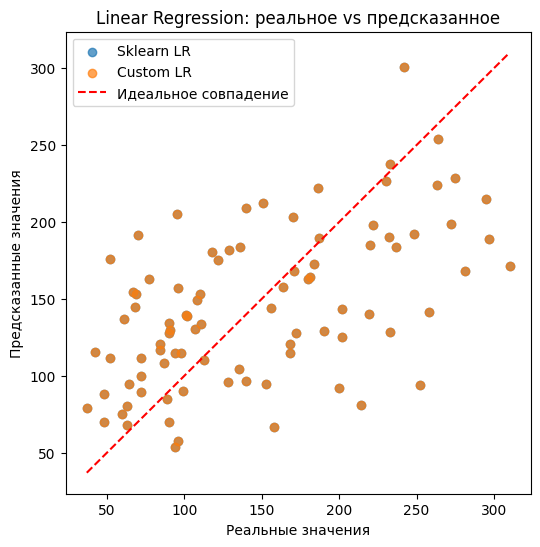

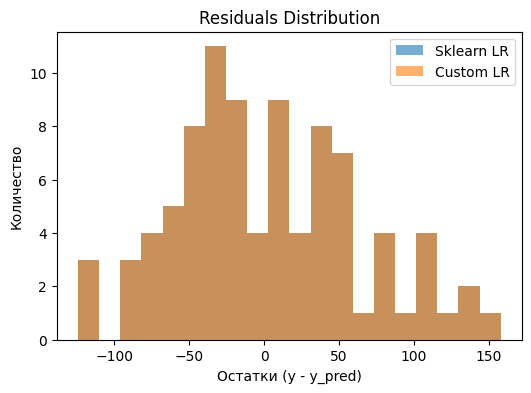

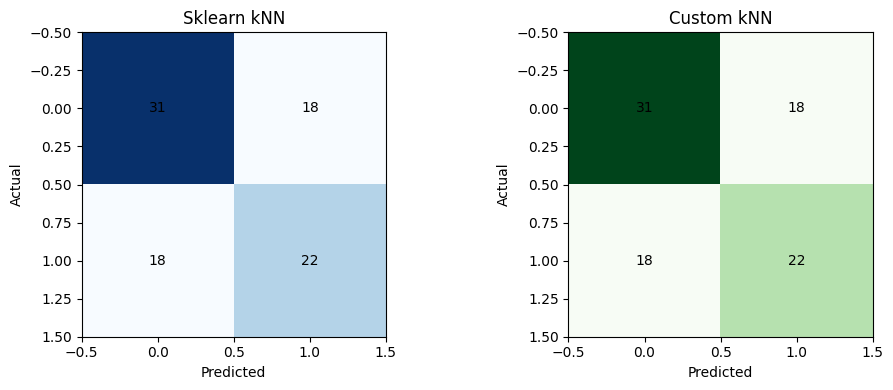

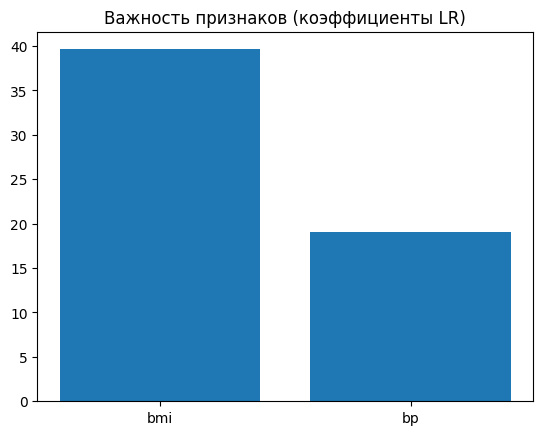

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

data = load_diabetes(as_frame=True)
df = data.frame.copy()

print("Размер датасета:", df.shape)
print(df.head())

print("\nИнфо:")
print(df.dtypes)
print("\nОписание:")
print(df.describe())
print("\nПроверка пропусков:")
print(df.isnull().sum())

feature_cols = ['bmi', 'bp']
X = df[feature_cols]
y_reg = df['target']
y_clf = (y_reg > y_reg.median()).astype(int)

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_reg)
y_pred_reg = lin_reg.predict(X_test_scaled)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_clf)
y_pred_clf = knn.predict(X_test_scaled)

mse_sklearn = mean_squared_error(y_test_reg, y_pred_reg)
r2_sklearn = r2_score(y_test_reg, y_pred_reg)
acc_sklearn = accuracy_score(y_test_clf, y_pred_clf)
prec_sklearn = precision_score(y_test_clf, y_pred_clf)
rec_sklearn = recall_score(y_test_clf, y_pred_clf)
f1_sklearn = f1_score(y_test_clf, y_pred_clf)

print("\n=== Sklearn Linear Regression ===")
print("MSE:", mse_sklearn)
print("R²:", r2_sklearn)

print("\n=== Sklearn kNN ===")
print("Accuracy:", acc_sklearn)
print("Precision:", prec_sklearn)
print("Recall:", rec_sklearn)
print("F1:", f1_sklearn)
print("Confusion matrix:\n", confusion_matrix(y_test_clf, y_pred_clf))

class CustomLinearRegression:
    def fit(self, X, y):
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        self.theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
    def predict(self, X):
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_b @ self.theta

custom_linreg = CustomLinearRegression()
custom_linreg.fit(X_train_scaled, y_train_reg)
y_pred_reg_custom = custom_linreg.predict(X_test_scaled)

mse_custom = mean_squared_error(y_test_reg, y_pred_reg_custom)
r2_custom = r2_score(y_test_reg, y_pred_reg_custom)

print("\n=== Custom Linear Regression ===")
print("MSE:", mse_custom)
print("R²:", r2_custom)

class CustomKNNClassifier:
    def __init__(self, k=5):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        preds = []
        for x in X:
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            k_idx = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_idx]
            vals, counts = np.unique(k_labels, return_counts=True)
            preds.append(vals[np.argmax(counts)])
        return np.array(preds)

custom_knn = CustomKNNClassifier(k=5)
custom_knn.fit(X_train_scaled, y_train_clf.values)
y_pred_clf_custom = custom_knn.predict(X_test_scaled)

acc_custom = accuracy_score(y_test_clf, y_pred_clf_custom)
prec_custom = precision_score(y_test_clf, y_pred_clf_custom)
rec_custom = recall_score(y_test_clf, y_pred_clf_custom)
f1_custom = f1_score(y_test_clf, y_pred_clf_custom)

print("\n=== Custom kNN ===")
print("Accuracy:", acc_custom)
print("Precision:", prec_custom)
print("Recall:", rec_custom)
print("F1:", f1_custom)
print("Confusion matrix:\n", confusion_matrix(y_test_clf, y_pred_clf_custom))

results = pd.DataFrame({
    "Model": ["Sklearn LinearRegression", "Custom LinearRegression",
              "Sklearn kNN", "Custom kNN"],
    "MSE (регрессия)": [mse_sklearn, mse_custom, None, None],
    "R² (регрессия)": [r2_sklearn, r2_custom, None, None],
    "Accuracy (классификация)": [None, None, acc_sklearn, acc_custom],
    "Precision": [None, None, prec_sklearn, prec_custom],
    "Recall": [None, None, rec_sklearn, rec_custom],
    "F1": [None, None, f1_sklearn, f1_custom]
})

print("\n=== Сравнение моделей ===")
print(results)
results.to_csv("lab_model_comparison.csv", index=False)

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.7, label="Sklearn LR")
plt.scatter(y_test_reg, y_pred_reg_custom, alpha=0.7, label="Custom LR")
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', label="Идеальное совпадение")
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.legend()
plt.title("Linear Regression: реальное vs предсказанное")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(y_test_reg - y_pred_reg, bins=20, alpha=0.6, label="Sklearn LR")
plt.hist(y_test_reg - y_pred_reg_custom, bins=20, alpha=0.6, label="Custom LR")
plt.xlabel("Остатки (y - y_pred)")
plt.ylabel("Количество")
plt.legend()
plt.title("Residuals Distribution")
plt.show()

cm = confusion_matrix(y_test_clf, y_pred_clf)
cm_custom = confusion_matrix(y_test_clf, y_pred_clf_custom)

fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].imshow(cm, cmap="Blues")
ax[0].set_title("Sklearn kNN")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax[0].text(j, i, cm[i, j], ha="center", va="center", color="black")

ax[1].imshow(cm_custom, cmap="Greens")
ax[1].set_title("Custom kNN")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
for i in range(cm_custom.shape[0]):
    for j in range(cm_custom.shape[1]):
        ax[1].text(j, i, cm_custom[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

coef = lin_reg.coef_
plt.bar(feature_cols, coef)
plt.title("Важность признаков (коэффициенты LR)")
plt.show()
